In [1]:
import numpy as np 

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False
%matplotlib inline

In [17]:
# c350, c420, c450
metro_cates = np.array([-2354.52, -1167.07, -5537.23])
metro_sig_cates = np.array([5236.84, 1728.14, 2474.44])

# c360, c520, c530, c540, c610, c620, c630
metro_med_ctes = np.array([-7784.32, -197.77, -8311.84, -4007.17, -9469.35, -21196.17, -3966.46])
metro_sig_med_ctes = np.array([545.91, 1069.94, 1630.07, 2149.90, 3697.56, 910.59, 993.53])

In [18]:
# c350, c420, c450
micro_cates = np.array([None, None, 1004.23])
micro_sig_cates = np.array([None, None, 635.61])

# c360, c520, c530, c540, c610, c620, c630
micro_med_ctes = np.array([-14398., -7127.48, -1053, -17894.79, -8376.31, None, -8325.14])
micro_sig_med_ctes = np.array([6490.71, 7980.59, None, 24156.32, 2627.85, None, 6309.80])

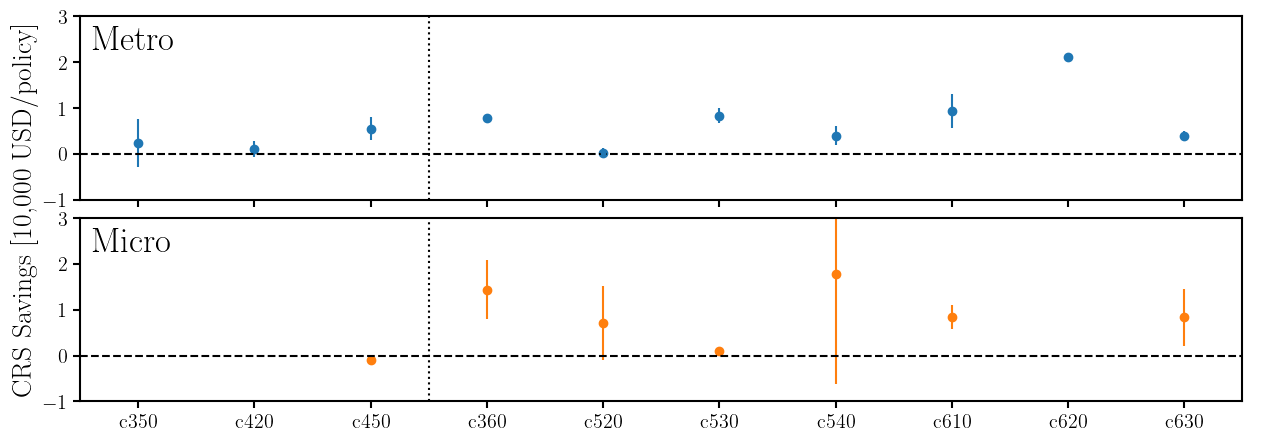

In [24]:
fig = plt.figure(figsize=(15,5))

# metropolitan
sub = fig.add_subplot(2,1,1)

sub.errorbar(np.arange(3), -metro_cates/1e4, yerr=metro_sig_cates/1e4, fmt='.C0')    
sub.scatter(np.arange(3),  -metro_cates/1e4, c='C0')  
    
sub.errorbar(np.arange(3, 10), -metro_med_ctes/1e4, yerr=metro_sig_med_ctes/1e4, fmt='.C0')
sub.scatter(np.arange(3, 10),  -metro_med_ctes/1e4, c='C0')    
    
sub.text(0.01, 0.95, 'Metro', transform=sub.transAxes, ha='left', va='top', fontsize=25)
sub.axhline(0., color='k', linestyle='--')    
sub.set_xlim(-0.5, 9.5)
sub.set_xticks(np.arange(10))
sub.set_xticklabels([])
sub.set_ylim(-1., 3.)
sub.axvline(2.5, color='k', linestyle=':')

sub = fig.add_subplot(2,1,2)

for x, y, ye in zip(np.arange(3), micro_cates, micro_sig_cates): 
    if y is None: continue
    sub.errorbar([x], [-y/1e4], yerr=[ye/1e4], fmt='.C1')    
    sub.scatter([x], [-y/1e4], c='C1')  

for x, y, ye in zip(np.arange(3, 10), micro_med_ctes, micro_sig_med_ctes): 
    if y is None: continue
    if ye is not None: sub.errorbar([x], [-y/1e4], yerr=[ye/1e4], fmt='.C1')    
    sub.scatter([x], [-y/1e4], c='C1')  
#sub.errorbar(np.arange(3, 10), -metro_med_ctes/1e4, yerr=metro_sig_med_ctes/1e4, fmt='.C0')
#sub.scatter(np.arange(3, 10),  -metro_med_ctes/1e4, c='C0')    
    
sub.text(0.01, 0.95, 'Micro', transform=sub.transAxes, ha='left', va='top', fontsize=25)
sub.axhline(0., color='k', linestyle='--')    
sub.set_xlim(-0.5, 9.5)
sub.set_xticks(np.arange(10))
sub.set_xticklabels([])
sub.set_ylim(-1., 3.)
sub.axvline(2.5, color='k', linestyle=':')
sub.set_xticklabels(['c350', 'c420', 'c450', 'c360', 'c520', 'c530', 'c540', 'c610', 'c620', 'c630'])


fig.subplots_adjust(hspace=0.1)
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.ylabel("CRS Savings [10,000 USD/policy]", fontsize=20)
fig.savefig('crs_activities.pdf', bbox_inches='tight')